In [31]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data.dataloader import DataLoader

In [32]:
# Hyper parameters
num_classes = 10
batch_size = 64
num_channels = 1
img_size = 28
path_size = 7
num_patches = (img_size//path_size)**2
embedding_dim = 64 # image patch enmbedding
attention_heads = 4
transformer_bolcks = 4
mlp_hidden_nodes = 128
learning_rate = 0.001
epochs = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
# Transformation for PIL to tensor format
transformation_operation = transforms.Compose([
    transforms.ToTensor()
])

In [34]:
# Load data
train_dataset = torchvision.datasets.MNIST(root="./data",train=True, transform=transformation_operation)
val_dataset = torchvision.datasets.MNIST(root="./data",train=False, transform=transformation_operation)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

part 1: Patch Embedding\
part 2: Transformer Encoder\
part 3: MLP_head\
part 4: Vision Transformer class

# Part 1: Patch Embedding

In [35]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embd = nn.Conv2d(
            in_channels=num_channels,
            out_channels=embedding_dim,
            kernel_size=path_size,
            stride=path_size
        )
        
    def forward(self, x):
        x = self.patch_embd(x) # (Batch_size=64,1,28,28) -> (64,64,4,4)
        x = x.flatten(2) # (64,64,4,4) -> (64,64,4*4=16)
        x = x.transpose(1,2) # (64,64,16) -> (64,16,64)
        
        return x


# Part 2: Transformer Encoder

In [36]:
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_dim)
        self.layer_norm2 = nn.LayerNorm(embedding_dim)
        self.multihead_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, mlp_hidden_nodes),
            nn.GELU(),
            nn.Linear(mlp_hidden_nodes, embedding_dim)
        )

    def forward(self, x):
        residual1 = x
        x = self.layer_norm1(x)
        x = self.multihead_attention(x, x, x)[0]
        x = x + residual1

        residual2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x)
        x = x + residual2

        return x


# Part 3: MLP_Head

In [37]:
class MLP_head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_dim)
        self.mlp_head = nn.Linear(embedding_dim, num_classes)
        
    def forward(self, x):
        x = self.layer_norm1(x)
        x = self.mlp_head(x)

        return x


# Part 4: Vision Transformer class

In [38]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        # class token
        self.cls_token = nn.Parameter(torch.randn(1,1,embedding_dim))
        # position embedding
        self.positional_embedding = nn.Parameter(torch.randn(1,num_patches+1,embedding_dim))
        # transformer blocks
        self.transformer_blocks = nn.Sequential(
            *[TransformerEncoder() for _ in range(transformer_bolcks)]
        )
        # class token passed into MLP head
        self.mlp_head = MLP_head()

    def forward(self, x):
        x = self.patch_embedding(x) # (64,16,64)
        B = x.size(0) # batch size
        class_tokens = self.cls_token.expand(B,-1,-1) # for 64 batch images; (1, 1, 64) -> (64, 1, 64)
        x = torch.cat((class_tokens,x),dim = 1)
        x = x + self.positional_embedding
        x = self.transformer_blocks(x)
        x = x[:,0] # for every batch i only take 0th
        x = self.mlp_head(x)
        
        return x


# Training

In [39]:
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [41]:
# traning loop

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_num_data = 0
    
    print(f"\nEpoch: {epoch+1}")
    for batch_idx, (images, labels) in enumerate(train_loader,start=1):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct = (preds==labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)
        total_correct += correct
        total_num_data += labels.size(0)
        
        if (batch_idx%100==0):
            print(f"    Batch {batch_idx:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100 * total_correct / total_num_data
    print(f"==> Epoch {epoch+1}: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}% ")



Epoch: 1
    Batch 100: Loss = 0.4919, Accuracy = 84.38%
    Batch 200: Loss = 0.5188, Accuracy = 84.38%
    Batch 300: Loss = 0.3011, Accuracy = 85.94%
    Batch 400: Loss = 0.1313, Accuracy = 96.88%
    Batch 500: Loss = 0.3459, Accuracy = 92.19%
    Batch 600: Loss = 0.1165, Accuracy = 95.31%
    Batch 700: Loss = 0.2225, Accuracy = 92.19%
    Batch 800: Loss = 0.1371, Accuracy = 93.75%
    Batch 900: Loss = 0.1177, Accuracy = 96.88%
==> Epoch 1: Total Loss = 342.4619, Accuracy = 88.48% 

Epoch: 2
    Batch 100: Loss = 0.1744, Accuracy = 95.31%
    Batch 200: Loss = 0.0872, Accuracy = 96.88%
    Batch 300: Loss = 0.0185, Accuracy = 100.00%
    Batch 400: Loss = 0.1207, Accuracy = 96.88%
    Batch 500: Loss = 0.0801, Accuracy = 98.44%
    Batch 600: Loss = 0.1372, Accuracy = 93.75%
    Batch 700: Loss = 0.1000, Accuracy = 93.75%
    Batch 800: Loss = 0.1169, Accuracy = 95.31%
    Batch 900: Loss = 0.0666, Accuracy = 96.88%
==> Epoch 2: Total Loss = 120.1913, Accuracy = 96.08% 

Epoc

# Evaluation

In [42]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
        
test_acc = 100.0 * correct / total
print(f"Val Accuracy = {test_acc:.2f}%")

Val Accuracy = 97.67%


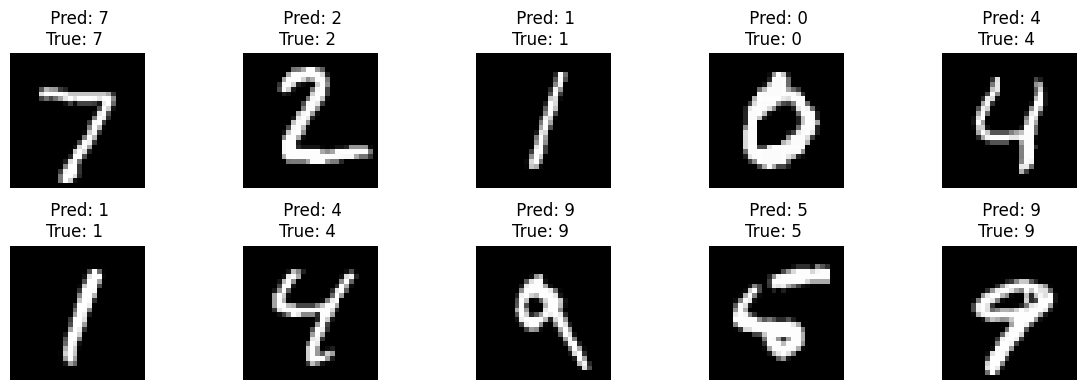

In [43]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)
# move to cpu
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

#plot first few images
plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(),cmap="grey")
    plt.title(f" Pred: {preds[i].item()}\nTrue: {labels[i].item()} ")
    plt.axis("off")
plt.tight_layout()
plt.show()